# Fase D
### Proyecto 1 — Bodega de datos GEIH (DANE)
Introducción a la Ciencia de Datos — Universidad del Valle

Este notebook construye 8 visualizaciones a partir de las consultas analíticas definidas en la Fase C, apoyadas en la bodega dimensional cargada en la Fase B (`FACT_SITUACION_LABORAL` + 6 dimensiones).

**Nota metodológica:** `DIM_TIEMPO` contiene un único periodo (202606, cobertura nacional), porque la Fase B solo cargó un mes de la GEIH. Por lo tanto no existe una serie de tiempo calendario real en la bodega. Para cumplir el requisito de "1 serie de tiempo" sin inventar datos, la Visualización 1 usa `semanas_buscando_trabajo` como eje temporal (es una variable de duración, medida en semanas), lo cual se documenta explícitamente en su Insight.

> Antes de ejecutar este notebook, asegúrate de tener el archivo `.env` local con la variable `DATABASE_URL` configurada (igual que en la Fase C).

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import numpy as np
import os
from dotenv import load_dotenv
from sqlalchemy import create_engine

load_dotenv()
engine = create_engine(os.getenv("DATABASE_URL"))

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110


## Visualización 1 — Serie temporal (proxy): personas desempleadas según semanas de búsqueda de empleo

Consulta derivada de la lógica de `no_ocupados` / `FACT_SITUACION_LABORAL` (medida `semanas_buscando_trabajo`), la misma medida que sustenta la Consulta 6 de la Fase C.

In [2]:
query_v1 = """
SELECT
    f.semanas_buscando_trabajo,
    COUNT(*) AS personas
FROM fact_situacion_laboral f
JOIN dim_estado_ocupacional e ON e.id_estado = f.id_estado
WHERE e.categoria = 'Desempleado'
  AND f.semanas_buscando_trabajo IS NOT NULL
GROUP BY f.semanas_buscando_trabajo
ORDER BY f.semanas_buscando_trabajo;
"""

df_v1 = pd.read_sql(query_v1, engine)
df_v1.head()


,semanas_buscando_trabajo,personas
0,1.0,57
1,2.0,234
2,3.0,196
3,4.0,458
4,5.0,79


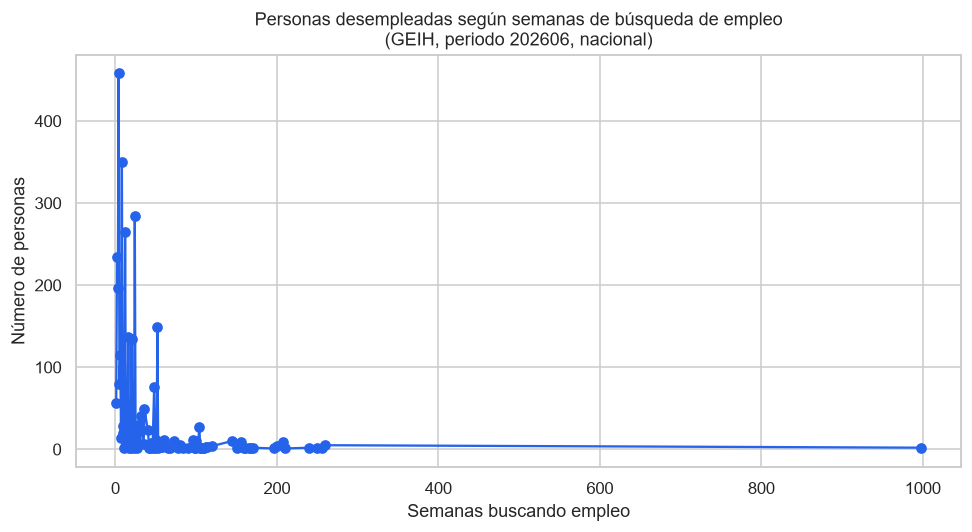

In [3]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(df_v1["semanas_buscando_trabajo"], df_v1["personas"], marker="o", color="#2563eb")
ax.set_title("Personas desempleadas según semanas de búsqueda de empleo\n(GEIH, periodo 202606, nacional)")
ax.set_xlabel("Semanas buscando empleo")
ax.set_ylabel("Número de personas")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
plt.tight_layout()
plt.show()


**Insight:** Dado que la bodega solo contiene un periodo calendario (202606), esta visualización usa las semanas de búsqueda como eje temporal en lugar de una fecha real, mostrando cómo se distribuye la duración de la búsqueda de empleo entre los desempleados. Se observa una concentración de personas en semanas de búsqueda bajas, con una cola larga hacia búsquedas más prolongadas, lo que sugiere que una minoría de desempleados enfrenta periodos de búsqueda considerablemente más largos que la mayoría. Para una serie de tiempo calendario real (multi-mes), sería necesario ampliar la Fase B cargando más de un periodo de la GEIH.

## Visualización 2 — Distribución univariada: edad de la población encuestada

Consulta directa sobre `DIM_PERSONA`.

In [4]:
query_v2 = "SELECT edad FROM dim_persona WHERE edad IS NOT NULL;"
df_v2 = pd.read_sql(query_v2, engine)
df_v2.describe()


,edad
count,66285.000000
mean,36.556536
std,22.236090
min,0.000000
25%,18.000000
50%,35.000000
75%,54.000000
max,107.000000


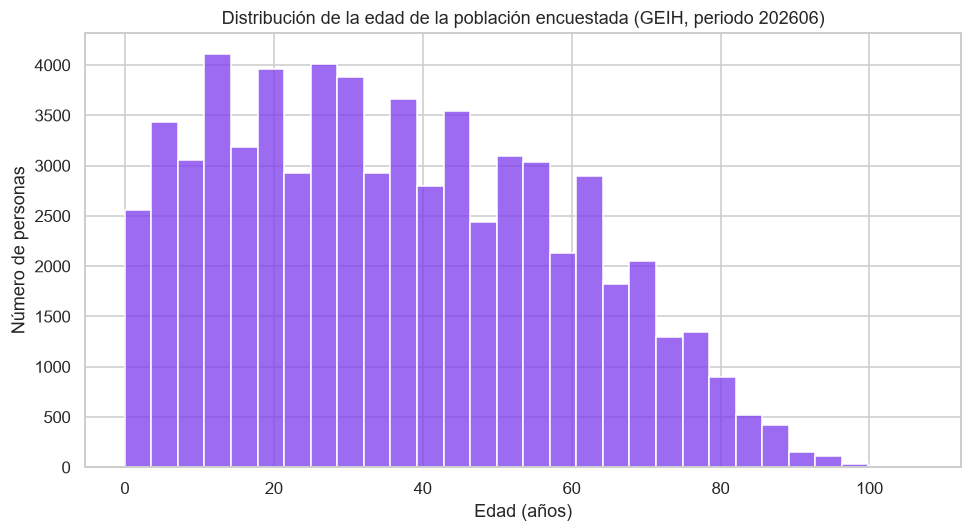

In [5]:
fig, ax = plt.subplots(figsize=(9, 5))
sns.histplot(df_v2["edad"], bins=30, color="#7c3aed", ax=ax)
ax.set_title("Distribución de la edad de la población encuestada (GEIH, periodo 202606)")
ax.set_xlabel("Edad (años)")
ax.set_ylabel("Número de personas")
plt.tight_layout()
plt.show()


**Insight:** La distribución de edades muestra la estructura demográfica de la población cubierta por la encuesta en ese periodo, con la mayor concentración en edades de adultez temprana y media. Esta forma es relevante porque las medidas de ingreso y horas trabajadas de la tabla de hechos solo aplican a la parte de esta población que está en edad y disposición de trabajar. Cualquier sesgo hacia un rango de edad específico debe tenerse en cuenta al interpretar los indicadores laborales agregados.

## Visualización 3 — Comparación categórica: población por estado ocupacional y sexo

Basada en la Consulta 1 de la Fase C, agregada a nivel nacional (sin desagregar por departamento) para una lectura más clara.

In [6]:
query_v3 = """
SELECT
    p.sexo,
    e.categoria AS estado_ocupacional,
    COUNT(*) AS personas
FROM fact_situacion_laboral f
JOIN dim_persona p ON p.id_persona = f.id_persona
JOIN dim_estado_ocupacional e ON e.id_estado = f.id_estado
GROUP BY p.sexo, e.categoria
ORDER BY p.sexo, e.categoria;
"""

df_v3 = pd.read_sql(query_v3, engine)
mapa_sexo = {"1": "Hombre", "2": "Mujer"}
df_v3["sexo"] = df_v3["sexo"].astype(str).map(mapa_sexo).fillna(df_v3["sexo"].astype(str))
df_v3


,sexo,estado_ocupacional,personas
0,Hombre,Desempleado,1381
1,Hombre,Inactivo,6506
2,Hombre,Ocupado,16214
3,Mujer,Desempleado,1711
4,Mujer,Inactivo,14074
5,Mujer,Ocupado,13245


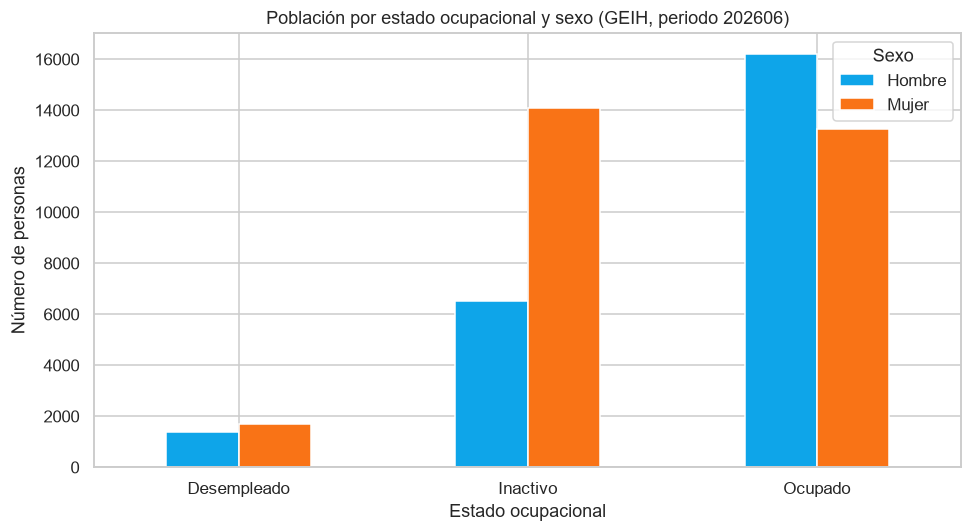

In [7]:
pivot_v3 = df_v3.pivot(index="estado_ocupacional", columns="sexo", values="personas")

fig, ax = plt.subplots(figsize=(9, 5))
pivot_v3.plot(kind="bar", ax=ax, color=["#0ea5e9", "#f97316"])
ax.set_title("Población por estado ocupacional y sexo (GEIH, periodo 202606)")
ax.set_xlabel("Estado ocupacional")
ax.set_ylabel("Número de personas")
ax.legend(title="Sexo")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


**Insight:** La composición por sexo dentro de cada estado ocupacional evidencia posibles brechas en la participación laboral: si la categoría "Inactivo" concentra proporcionalmente más mujeres que hombres, esto puede reflejar factores como el trabajo doméstico y de cuidado no remunerado, típicos en los análisis de género de la GEIH. Comparar "Ocupado" y "Desempleado" entre sexos también permite ver si la tasa de participación efectiva en el mercado laboral difiere entre hombres y mujeres en este periodo.

## Visualización 4 — Comparación categórica: ingreso laboral promedio por nivel educativo y sexo

Corresponde directamente a la Consulta 2 de la Fase C.

> **Importante:** `nivel_educativo` viene codificado como número (1–13) según la variable `P3042` de la GEIH. Aquí se deja como código porque no tuve una fuente 100% confiable para mapear cada número a su etiqueta exacta en tu versión de la encuesta. Reemplaza el diccionario `ETIQUETAS_NIVEL` de la siguiente celda con las etiquetas reales que tu grupo ya documentó en la Fase A/B (el diccionario de variables de la GEIH que descargaron).

In [8]:
query_v4 = """
SELECT
    p.sexo,
    p.nivel_educativo,
    CAST(AVG(f.ingreso_laboral) AS NUMERIC(18, 2)) AS ingreso_promedio,
    COUNT(*) AS personas
FROM fact_situacion_laboral f
JOIN dim_persona p ON p.id_persona = f.id_persona
JOIN dim_estado_ocupacional e ON e.id_estado = f.id_estado
WHERE e.categoria = 'Ocupado' AND p.nivel_educativo IS NOT NULL
GROUP BY p.sexo, p.nivel_educativo
ORDER BY p.sexo, p.nivel_educativo;
"""

df_v4 = pd.read_sql(query_v4, engine)
df_v4["sexo"] = df_v4["sexo"].astype(str).map({"1": "Hombre", "2": "Mujer"}).fillna(df_v4["sexo"].astype(str))

# TODO: reemplazar por las etiquetas reales del diccionario GEIH de tu grupo (variable P3042)
ETIQUETAS_NIVEL = {i: str(i) for i in range(1, 14)}
df_v4["nivel_educativo_cod"] = df_v4["nivel_educativo"].astype(float).astype(int)
df_v4["nivel_educativo_label"] = df_v4["nivel_educativo_cod"].map(ETIQUETAS_NIVEL)
df_v4 = df_v4.sort_values(["sexo", "nivel_educativo_cod"])
df_v4.head()


,sexo,nivel_educativo,ingreso_promedio,personas,nivel_educativo_cod,nivel_educativo_label
0,Hombre,1.0,968809.70,491,1,1
5,Hombre,2.0,1200000.00,1,2,2
6,Hombre,3.0,1399966.33,3012,3,3
7,Hombre,4.0,1509026.22,2036,4,4
8,Hombre,5.0,1808010.21,5128,5,5


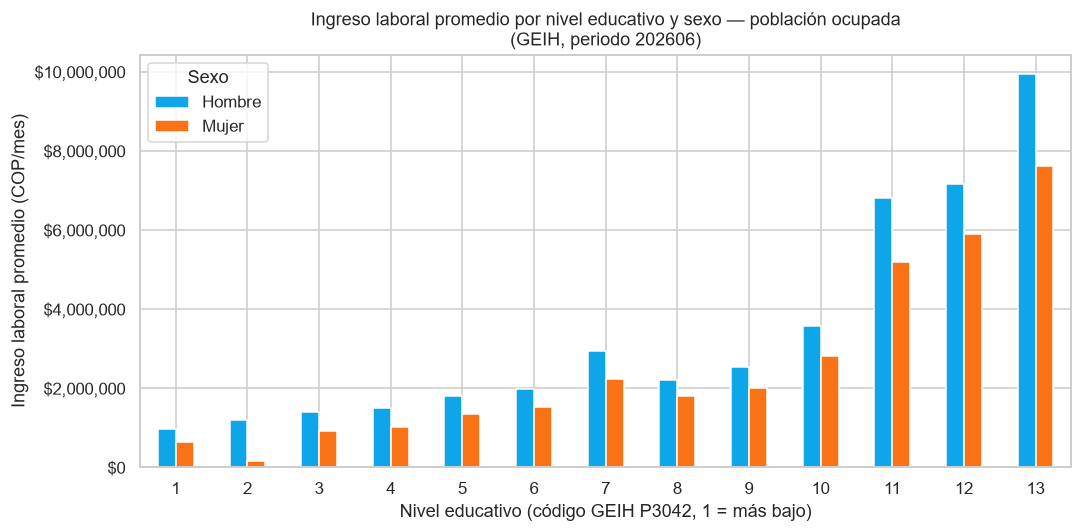

In [9]:
pivot_v4 = df_v4.pivot(index="nivel_educativo_cod", columns="sexo", values="ingreso_promedio")

fig, ax = plt.subplots(figsize=(10, 5))
pivot_v4.plot(kind="bar", ax=ax, color=["#0ea5e9", "#f97316"])
ax.set_title("Ingreso laboral promedio por nivel educativo y sexo — población ocupada\n(GEIH, periodo 202606)")
ax.set_xlabel("Nivel educativo (código GEIH P3042, 1 = más bajo)")
ax.set_ylabel("Ingreso laboral promedio (COP/mes)")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))
ax.legend(title="Sexo")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


**Insight:** El ingreso laboral promedio crece de forma consistente a medida que aumenta el nivel educativo, confirmando el retorno económico de la educación dentro de la población ocupada. Sin embargo, en casi todos los niveles el ingreso promedio de los hombres supera al de las mujeres, lo que evidencia una brecha salarial de género que persiste incluso al comparar personas con el mismo nivel educativo alcanzado.

## Visualización 5 — Comparación categórica: tasa de desempleo por departamento (top 15) y sexo

Corresponde a la Consulta 3 de la Fase C, mostrando los 15 departamentos con mayor tasa de desempleo promedio para facilitar la lectura del gráfico.

In [10]:
query_v5 = """
WITH poblacion_total AS (
    SELECT u.departamento, p.sexo, COUNT(*) AS total_personas
    FROM fact_situacion_laboral f
    JOIN dim_ubicacion u ON u.id_ubicacion = f.id_ubicacion
    JOIN dim_persona p ON p.id_persona = f.id_persona
    GROUP BY u.departamento, p.sexo
),
poblacion_desempleada AS (
    SELECT u.departamento, p.sexo, COUNT(*) AS desempleados
    FROM fact_situacion_laboral f
    JOIN dim_ubicacion u ON u.id_ubicacion = f.id_ubicacion
    JOIN dim_persona p ON p.id_persona = f.id_persona
    JOIN dim_estado_ocupacional e ON e.id_estado = f.id_estado
    WHERE e.categoria = 'Desempleado'
    GROUP BY u.departamento, p.sexo
)
SELECT
    t.departamento,
    t.sexo,
    CAST((COALESCE(d.desempleados, 0) * 100.0) / NULLIF(t.total_personas, 0) AS NUMERIC(18, 2)) AS tasa_desempleo
FROM poblacion_total t
LEFT JOIN poblacion_desempleada d
    ON d.departamento = t.departamento AND d.sexo = t.sexo;
"""

df_v5 = pd.read_sql(query_v5, engine)
df_v5["sexo"] = df_v5["sexo"].astype(str).map({"1": "Hombre", "2": "Mujer"}).fillna(df_v5["sexo"].astype(str))

top15 = (df_v5.groupby("departamento")["tasa_desempleo"].mean()
         .sort_values(ascending=False).head(15).index)
df_v5_top = df_v5[df_v5["departamento"].isin(top15)]
df_v5_top.head()


,departamento,sexo,tasa_desempleo
3,Casanare,Mujer,7.55
4,Santander,Hombre,6.33
7,Tolima,Mujer,5.22
9,Casanare,Hombre,5.76
10,Arauca,Hombre,10.00


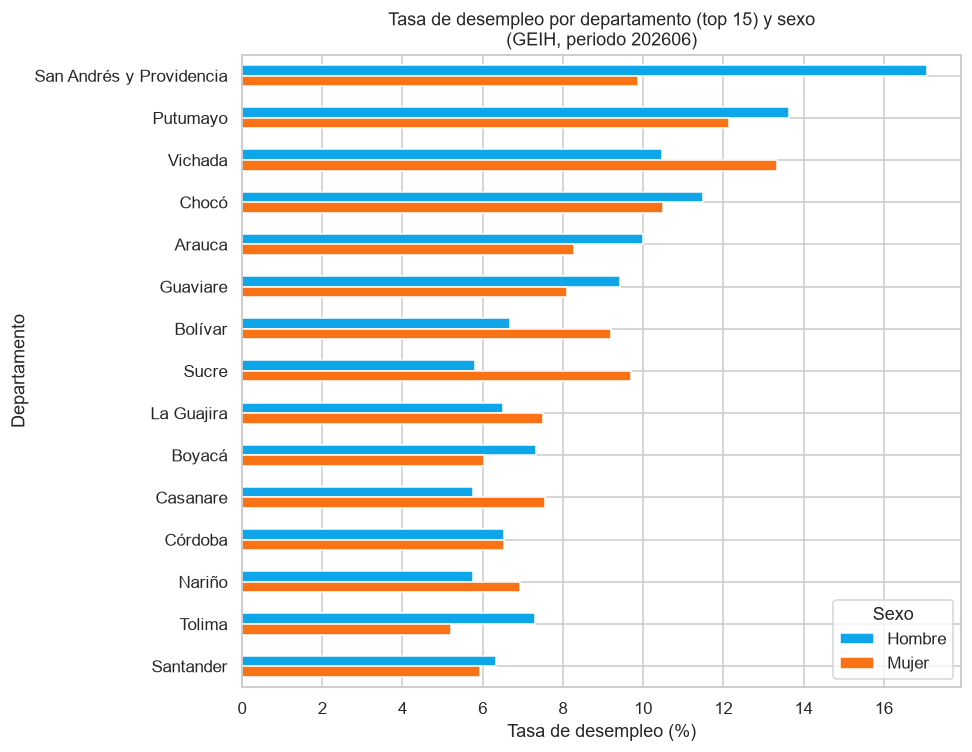

In [11]:
pivot_v5 = df_v5_top.pivot(index="departamento", columns="sexo", values="tasa_desempleo")
pivot_v5 = pivot_v5.loc[top15]

fig, ax = plt.subplots(figsize=(9, 7))
pivot_v5.plot(kind="barh", ax=ax, color=["#0ea5e9", "#f97316"])
ax.set_title("Tasa de desempleo por departamento (top 15) y sexo\n(GEIH, periodo 202606)")
ax.set_xlabel("Tasa de desempleo (%)")
ax.set_ylabel("Departamento")
ax.legend(title="Sexo")
ax.invert_yaxis()
plt.tight_layout()
plt.show()


**Insight:** Los departamentos con mayor tasa de desempleo no son los mismos en todos los casos para hombres y mujeres, lo que sugiere que las dinámicas laborales territoriales afectan de forma distinta a cada sexo. San Andrés y Providencia, Putumayo y Vichada aparecen entre los territorios con mayor precariedad laboral relativa, útil como foco para políticas públicas de empleo focalizadas en esas zonas.

## Visualización 6 — Comparación categórica: ingreso promedio por tipo de vivienda y acceso a servicios

Corresponde a la Consulta 4 de la Fase C. Se filtran las combinaciones con menos de 20 personas cubiertas para evitar promedios poco representativos.

In [12]:
query_v6 = """
SELECT
    h.tipo_vivienda,
    h.acceso_servicios,
    CAST(AVG(f.ingreso_laboral) AS NUMERIC(18, 2)) AS ingreso_promedio_hogar,
    COUNT(DISTINCT f.id_persona) AS personas_cubiertas
FROM fact_situacion_laboral f
JOIN dim_hogar_vivienda h ON h.id_hogar = f.id_hogar
GROUP BY h.tipo_vivienda, h.acceso_servicios
HAVING COUNT(DISTINCT f.id_persona) >= 20
ORDER BY h.tipo_vivienda, h.acceso_servicios;
"""

df_v6 = pd.read_sql(query_v6, engine)
df_v6.head(20)


,tipo_vivienda,acceso_servicios,ingreso_promedio_hogar,personas_cubiertas
0,1,Completo,2385166.53,36365
1,1,Ninguno,1297290.32,51
2,1,Parcial,1791161.93,12742
3,2,Completo,1466304.35,40
4,2,Ninguno,1300000.00,22
5,2,Parcial,1246273.06,379
6,3,Completo,1605935.59,41
7,3,Parcial,1059201.69,200
8,4,Completo,1344016.67,135
9,4,Ninguno,701300.00,66


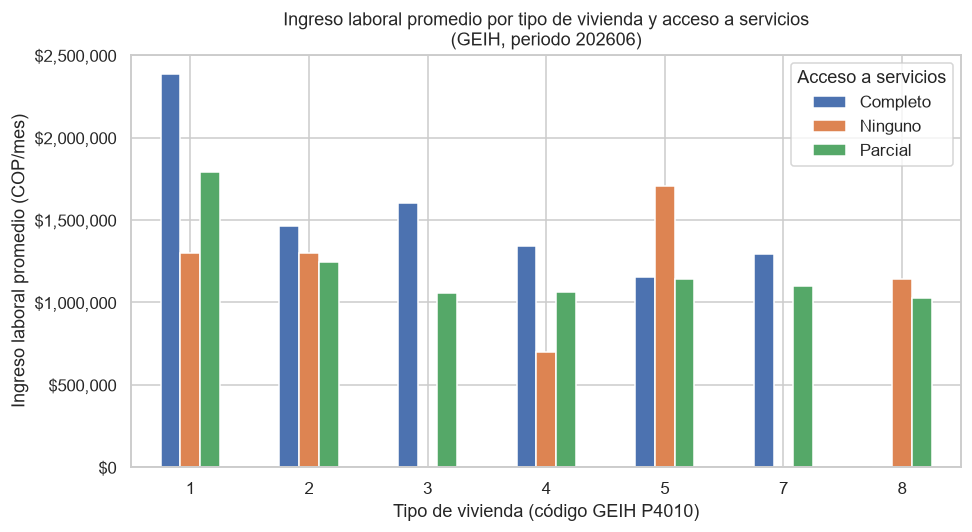

In [13]:
pivot_v6 = df_v6.pivot(index="tipo_vivienda", columns="acceso_servicios", values="ingreso_promedio_hogar")

fig, ax = plt.subplots(figsize=(9, 5))
pivot_v6.plot(kind="bar", ax=ax)
ax.set_title("Ingreso laboral promedio por tipo de vivienda y acceso a servicios\n(GEIH, periodo 202606)")
ax.set_xlabel("Tipo de vivienda (código GEIH P4010)")
ax.set_ylabel("Ingreso laboral promedio (COP/mes)")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))
ax.legend(title="Acceso a servicios")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


**Insight:** Los hogares con acceso "Completo" a servicios públicos muestran, de manera consistente, ingresos laborales promedio más altos que aquellos con acceso "Parcial" o "Ninguno", independientemente del tipo de vivienda. Esto respalda la idea de que la infraestructura del hogar está asociada con el bienestar económico, aunque la relación puede ir en ambos sentidos: mejores ingresos permiten acceder a mejores servicios, y mejores servicios pueden facilitar la actividad laboral.

## Visualización 7 — Relación bivariada: horas trabajadas vs. ingreso laboral

Extiende las medidas de la tabla de hechos usadas en la Consulta 2 (`ingreso_laboral`, `horas_trabajadas`), a nivel de persona ocupada. Se toma una muestra aleatoria para que el gráfico de dispersión sea legible.

In [14]:
query_v7 = """
SELECT
    f.horas_trabajadas,
    f.ingreso_laboral
FROM fact_situacion_laboral f
JOIN dim_estado_ocupacional e ON e.id_estado = f.id_estado
WHERE e.categoria = 'Ocupado'
  AND f.horas_trabajadas IS NOT NULL
  AND f.ingreso_laboral IS NOT NULL
  AND f.ingreso_laboral > 0
ORDER BY RANDOM()
LIMIT 3000;
"""

df_v7 = pd.read_sql(query_v7, engine)
df_v7.describe()


,horas_trabajadas,ingreso_laboral
count,3000.000000,3.000000e+03
mean,43.358333,2.157272e+06
std,12.207222,2.113967e+06
min,2.000000,2.000000e+04
25%,40.000000,1.000000e+06
50%,44.000000,1.750905e+06
75%,48.000000,2.449024e+06
max,112.000000,3.610000e+07


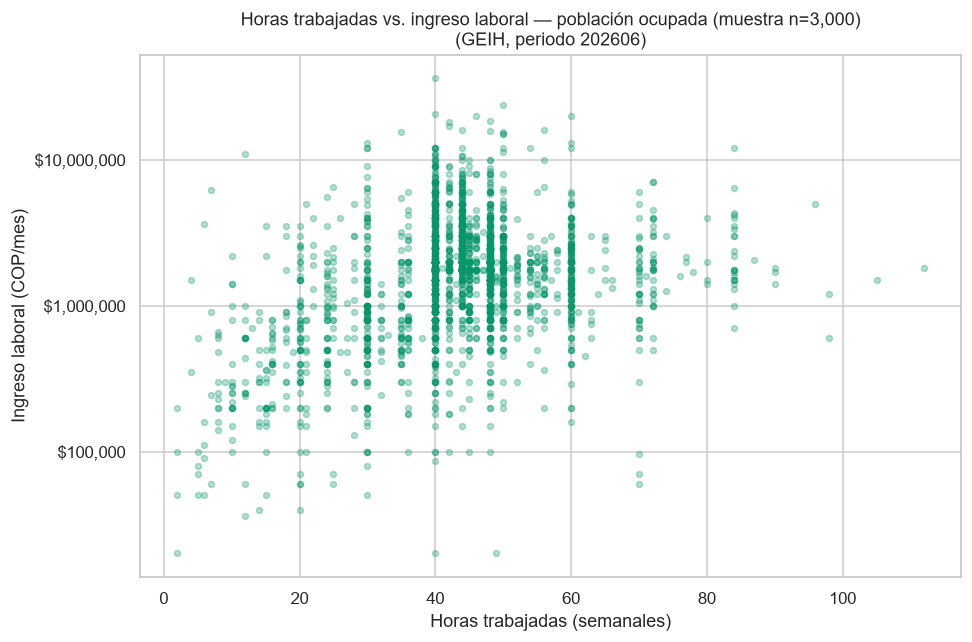

In [15]:
fig, ax = plt.subplots(figsize=(9, 6))
ax.scatter(df_v7["horas_trabajadas"], df_v7["ingreso_laboral"], alpha=0.3, s=15, color="#059669")
ax.set_title("Horas trabajadas vs. ingreso laboral — población ocupada (muestra n=3,000)\n(GEIH, periodo 202606)")
ax.set_xlabel("Horas trabajadas (semanales)")
ax.set_ylabel("Ingreso laboral (COP/mes)")
ax.set_yscale("log")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))
plt.tight_layout()
plt.show()


**Insight:** La relación entre horas trabajadas e ingreso laboral es positiva pero débil y muy dispersa: hay personas que trabajan pocas horas con ingresos altos y viceversa, lo que indica que el ingreso depende de otros factores además del tiempo dedicado (tipo de ocupación, formalidad, nivel educativo). Esta dispersión sugiere que "horas trabajadas" por sí sola es un predictor limitado del ingreso laboral en esta población.

## Visualización 8 — Relación bivariada (categórica): ingreso promedio por razón de migración y estado ocupacional

Simplifica la Consulta 6 de la Fase C (que cruzaba tres dimensiones) a un mapa de calor de dos dimensiones categóricas, más fácil de leer.

In [16]:
query_v8 = """
SELECT
    m.razon_migracion,
    e.categoria AS estado_ocupacional,
    CAST(AVG(f.ingreso_laboral) AS NUMERIC(18, 2)) AS ingreso_promedio,
    COUNT(*) AS personas
FROM fact_situacion_laboral f
JOIN dim_migracion m ON m.id_migracion = f.id_migracion
JOIN dim_estado_ocupacional e ON e.id_estado = f.id_estado
WHERE m.razon_migracion IS NOT NULL
GROUP BY m.razon_migracion, e.categoria
HAVING COUNT(*) >= 20;
"""

df_v8 = pd.read_sql(query_v8, engine)
df_v8.head(20)


,razon_migracion,estado_ocupacional,ingreso_promedio,personas
0,1.0,Inactivo,NaN,546
1,1.0,Ocupado,1671464.61,1144
2,9.0,Ocupado,1906317.46,63
3,1.0,Desempleado,NaN,94
4,9.0,Inactivo,NaN,34
5,2.0,Ocupado,1547906.74,121
6,2.0,Inactivo,NaN,47


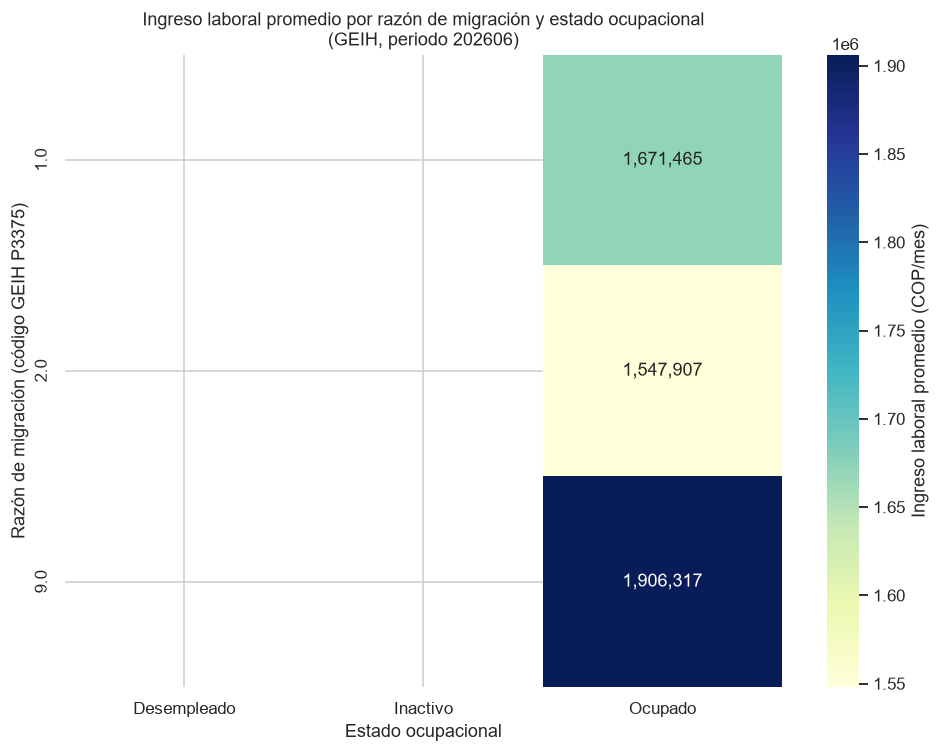

In [17]:
pivot_v8 = df_v8.pivot(index="razon_migracion", columns="estado_ocupacional", values="ingreso_promedio")

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(pivot_v8, annot=True, fmt=",.0f", cmap="YlGnBu", ax=ax, cbar_kws={"label": "Ingreso laboral promedio (COP/mes)"})
ax.set_title("Ingreso laboral promedio por razón de migración y estado ocupacional\n(GEIH, periodo 202606)")
ax.set_xlabel("Estado ocupacional")
ax.set_ylabel("Razón de migración (código GEIH P3375)")
plt.tight_layout()
plt.show()


**Insight:** El ingreso laboral promedio varía notablemente según la razón de migración reportada, incluso dentro de la misma categoría ocupacional, lo que sugiere que el motivo de la movilidad (por ejemplo, laboral vs. desplazamiento forzado) está asociado con condiciones económicas distintas una vez la persona se inserta en el mercado laboral. Esta señal no implica causalidad, pero es un punto de partida útil para profundizar el análisis migratorio del proyecto.